# 🧠 Notebook 2 — Baseline ResNet-50 on APTOS 2019

**Model**: ResNet-50 (ImageNet-pretrained) — **no CBAM**, plain backbone  
**Loss**: Focal Loss (γ=2.0) with per-class alpha weights  
**Optimizer**: AdamW + CosineAnnealingLR  
**Preprocessing**: Ben Graham (circular crop + Gaussian-blur color normalization)  
**Hardware**: CPU 16 GB — 5 epochs  

---

## 1. Setup

In [8]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import (
    cohen_kappa_score, accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)

from config import (
    APTOS_TRAIN_CSV, APTOS_TRAIN_IMAGES,
    IMAGE_SIZE, IMAGENET_MEAN, IMAGENET_STD,
    RANDOM_SEED, WEIGHT_DECAY,
    NUM_CLASSES, FOCAL_GAMMA, MC_DROPOUT_RATE,
    DR_GRADES, DR_COLORS,
    CHECKPOINT_DIR, LOG_DIR, RESULTS_DIR, FIGURES_DIR,
    seed_everything, setup_directories
)
from dataset import get_train_val_split, create_dataloaders
from loss import FocalLoss, compute_class_weights
from preprocessing import ben_graham_preprocess

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── CPU-friendly overrides ──
EPOCHS = 5              # quick run
BATCH_SIZE = 4           # fits in 16 GB RAM with 512×512
LEARNING_RATE = 1e-4
NUM_WORKERS = 0          # 0 = main-process loading (safest on CPU/Windows)
EARLY_STOPPING_PATIENCE = 5

# Reproducibility
seed_everything(RANDOM_SEED)
setup_directories()

DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')
print(f'Epochs: {EPOCHS}  |  Batch size: {BATCH_SIZE}')

Device: cpu
Epochs: 5  |  Batch size: 4


## 2. Load & Split Data

In [9]:
df = pd.read_csv(APTOS_TRAIN_CSV)
train_df, val_df = get_train_val_split(df, val_fold=0)

print(f'Train: {len(train_df)}  |  Val: {len(val_df)}')
print(f'\nTrain distribution:')
print(train_df['diagnosis'].value_counts().sort_index())
print(f'\nVal distribution:')
print(val_df['diagnosis'].value_counts().sort_index())

Train: 2929  |  Val: 733

Train distribution:
diagnosis
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Val distribution:
diagnosis
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64


In [10]:
train_loader, val_loader = create_dataloaders(
    train_df, val_df, str(APTOS_TRAIN_IMAGES),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    image_size=IMAGE_SIZE, preprocess=True
)

# Verify batch shapes
images, labels = next(iter(train_loader))
print(f'Batch images: {images.shape}')  # (4, 3, 512, 512)
print(f'Batch labels: {labels.shape}')  # (4,)
print(f'Label values:  {labels.tolist()}')

c:\Projects\dr-detect\dr-env\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Projects\dr-detect\src\dataset.py:220: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),


Batch images: torch.Size([4, 3, 512, 512])
Batch labels: torch.Size([4])
Label values:  [0, 2, 0, 2]


## 3. Build Baseline ResNet-50

Plain ResNet-50 backbone **without CBAM**. Standard `nn.Dropout` in the head.

In [11]:
class BaselineResNet50(nn.Module):
    """Plain ResNet-50 baseline (no CBAM).
    
    Architecture:
        ResNet-50 backbone (ImageNet pretrained)
        → AdaptiveAvgPool2d → (B, 2048)
        → Dropout(0.5)
        → Linear(2048, 5)
    """

    def __init__(self, num_classes=NUM_CLASSES, dropout_rate=MC_DROPOUT_RATE,
                 pretrained=True):
        super().__init__()

        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = models.resnet50(weights=weights)

        # Everything except the final FC
        self.features = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


model = BaselineResNet50(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

# Quick shape check
with torch.no_grad():
    dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
    out = model(dummy)
    print(f'Output shape:     {out.shape}')  # (1, 5)

Total params:     23,518,277
Trainable params: 23,518,277
Output shape:     torch.Size([1, 5])


## 4. Loss, Optimizer & Scheduler

In [12]:
# Focal Loss with per-class alpha
train_labels = torch.tensor(train_df['diagnosis'].values)
alpha_weights = compute_class_weights(train_labels, NUM_CLASSES)
print(f'Class alpha weights: {alpha_weights.numpy().round(3)}')

criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha_weights)

# AdamW + Cosine Annealing
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'\nOptimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Scheduler: CosineAnnealingLR (T_max={EPOCHS})')
print(f'Loss:      FocalLoss (gamma={FOCAL_GAMMA})')
print(f'AMP:       Disabled (running on CPU)')

Class alpha weights: [0.406 1.979 0.733 3.804 2.482]

Optimizer: AdamW (lr=0.0001, wd=0.0001)
Scheduler: CosineAnnealingLR (T_max=5)
Loss:      FocalLoss (gamma=2.0)
AMP:       Disabled (running on CPU)


## 5. Training Loop

No AMP — pure float32 on CPU.

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    """Train for one epoch (CPU, no AMP)."""
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.detach().argmax(dim=1).numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, desc='Validating'):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        probs = F.softmax(logits, dim=1).numpy()
        preds = logits.argmax(dim=1).numpy()

        all_probs.append(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    all_probs = np.vstack(all_probs)
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    # Binary referable DR AUC
    binary_labels = (np.array(all_labels) >= 2).astype(int)
    binary_probs = all_probs[:, 2:].sum(axis=1)
    try:
        epoch_auc = roc_auc_score(binary_labels, binary_probs)
    except ValueError:
        epoch_auc = 0.0

    return epoch_loss, epoch_acc, epoch_kappa, epoch_auc, all_preds, all_labels, all_probs

In [14]:
# ── Training loop ──
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'val_kappa': [],  'val_auc': [], 'lr': []
}

best_kappa = -1.0
epochs_no_improve = 0
best_preds_info = None

print(f'\n{"="*60}')
print(f'  BASELINE ResNet-50 Training (CPU)')
print(f'  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}  |  AMP: off')
print(f'{"="*60}\n')

for epoch in range(EPOCHS):
    # Train
    t_loss, t_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, epoch
    )

    # Validate
    v_loss, v_acc, v_kappa, v_auc, preds, labels, probs = validate(
        model, val_loader, criterion, DEVICE
    )

    # Scheduler step
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    # Log
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    history['val_kappa'].append(v_kappa)
    history['val_auc'].append(v_auc)
    history['lr'].append(lr)

    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print(f'  Train — loss: {t_loss:.4f}  acc: {t_acc:.4f}')
    print(f'  Val   — loss: {v_loss:.4f}  acc: {v_acc:.4f}')
    print(f'  Val κ: {v_kappa:.4f}  AUC: {v_auc:.4f}  LR: {lr:.2e}')

    # Best model
    if v_kappa > best_kappa:
        best_kappa = v_kappa
        epochs_no_improve = 0
        best_preds_info = {
            'preds': np.array(preds),
            'labels': np.array(labels),
            'probs': probs
        }
        # Save checkpoint
        ckpt_path = CHECKPOINT_DIR / 'baseline_resnet50_fold0_best.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_kappa': best_kappa,
            'history': history,
        }, ckpt_path)
        print(f'  ✓ New best model saved (κ = {best_kappa:.4f})')
    else:
        epochs_no_improve += 1

    # Early stopping
    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f'\n  ⚠ Early stopping at epoch {epoch+1}')
        break

print(f'\n{"="*60}')
print(f'  Training complete — Best Val κ: {best_kappa:.4f}')
print(f'{"="*60}')


  BASELINE ResNet-50 Training (CPU)
  Epochs: 5  |  Batch: 4  |  AMP: off



Epoch 1/5 [Train]:   0%|          | 0/732 [00:00<?, ?it/s]

Validating:   0%|          | 0/184 [00:00<?, ?it/s]


Epoch 1/5
  Train — loss: 0.8037  acc: 0.5195
  Val   — loss: 0.7297  acc: 0.6166
  Val κ: 0.8274  AUC: 0.9742  LR: 9.05e-05
  ✓ New best model saved (κ = 0.8274)


Epoch 2/5 [Train]:   0%|          | 0/732 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/184 [00:00<?, ?it/s]


Epoch 4/5
  Train — loss: 0.4207  acc: 0.7459
  Val   — loss: 0.3724  acc: 0.8049
  Val κ: 0.8946  AUC: 0.9831  LR: 9.55e-06
  ✓ New best model saved (κ = 0.8946)


Epoch 5/5 [Train]:   0%|          | 0/732 [00:00<?, ?it/s]

Validating:   0%|          | 0/184 [00:00<?, ?it/s]


Epoch 5/5
  Train — loss: 0.3893  acc: 0.7732
  Val   — loss: 0.3671  acc: 0.7858
  Val κ: 0.8926  AUC: 0.9839  LR: 0.00e+00

  Training complete — Best Val κ: 0.8946


## 6. Training Curves

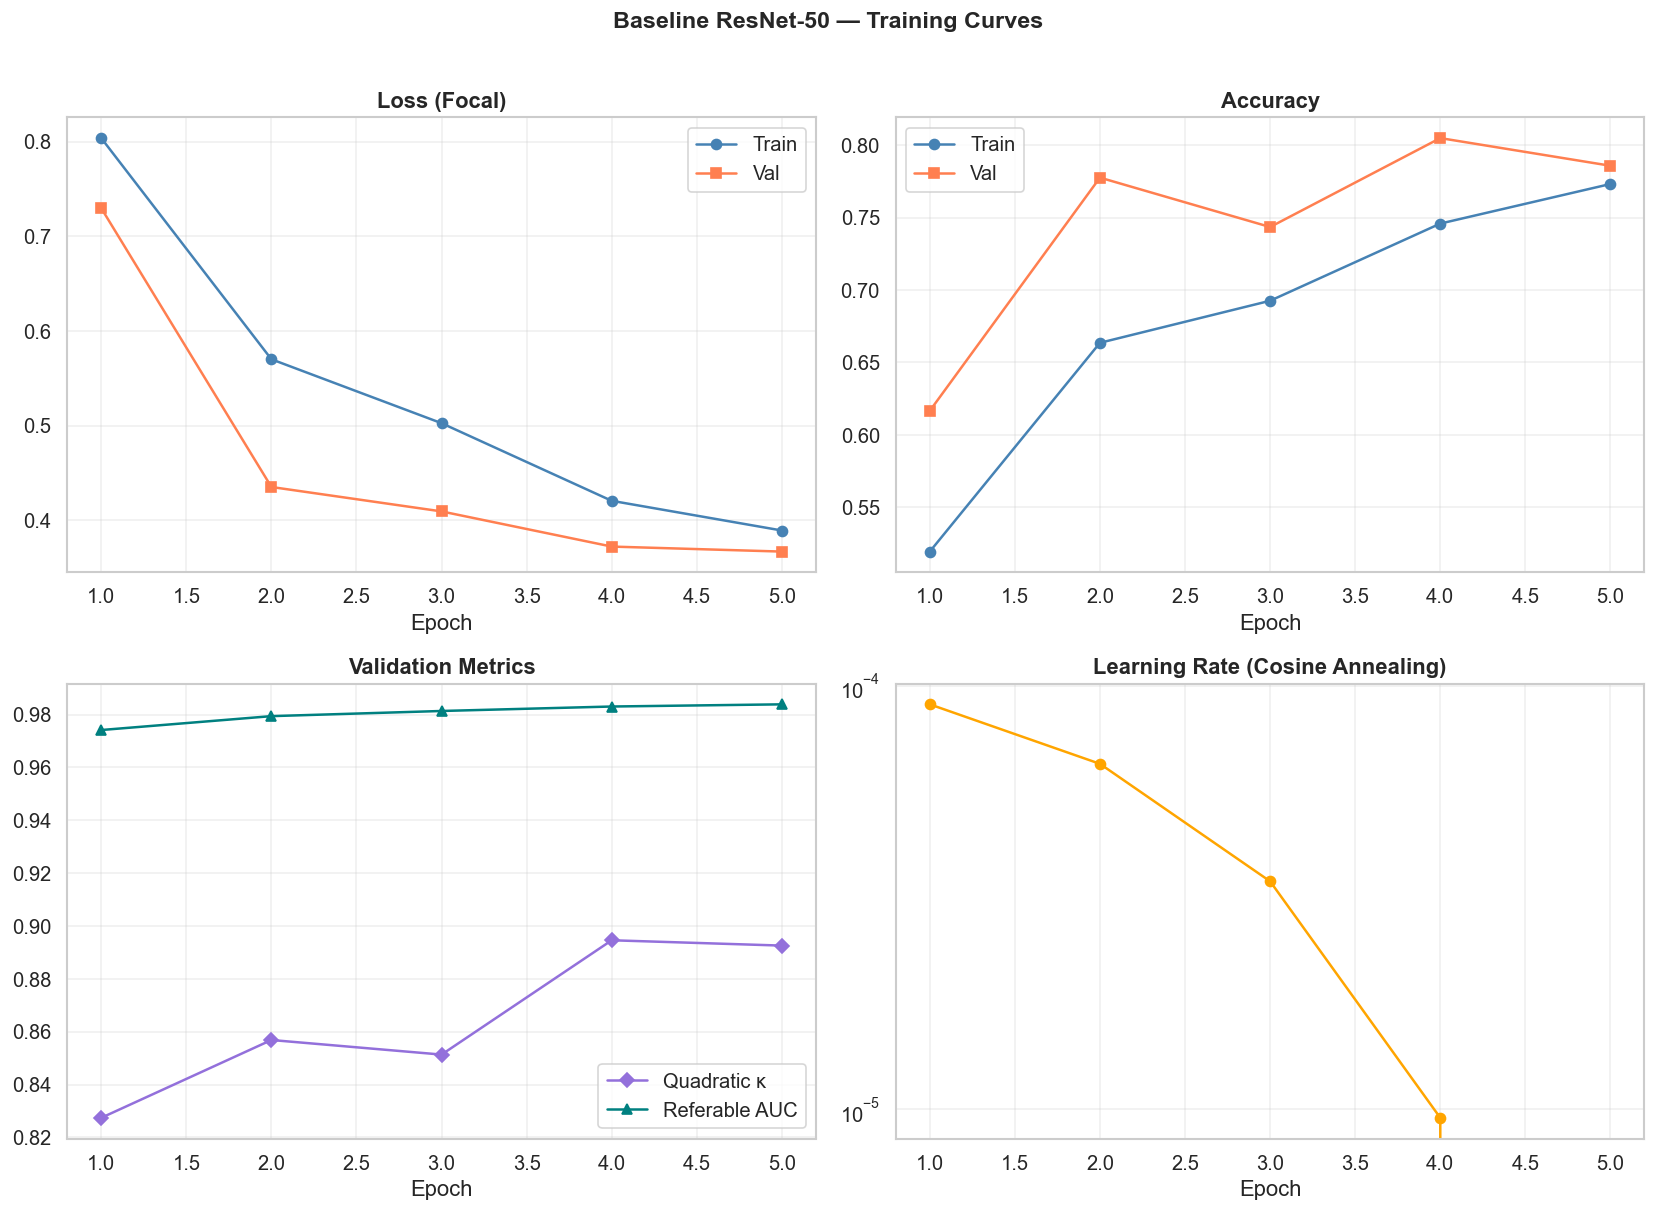

In [15]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='steelblue')
axes[0, 0].plot(epochs_range, history['val_loss'], 's-', label='Val', color='coral')
axes[0, 0].set_title('Loss (Focal)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='steelblue')
axes[0, 1].plot(epochs_range, history['val_acc'], 's-', label='Val', color='coral')
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Kappa + AUC
axes[1, 0].plot(epochs_range, history['val_kappa'], 'D-', label='Quadratic κ', color='mediumpurple')
axes[1, 0].plot(epochs_range, history['val_auc'], '^-', label='Referable AUC', color='teal')
axes[1, 0].set_title('Validation Metrics', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# LR schedule
axes[1, 1].plot(epochs_range, history['lr'], 'o-', color='orange')
axes[1, 1].set_title('Learning Rate (Cosine Annealing)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Baseline ResNet-50 — Training Curves', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_resnet50_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Evaluation on Best Model

In [16]:
# Use the best-epoch predictions
preds = best_preds_info['preds']
labels = best_preds_info['labels']
probs = best_preds_info['probs']

# Classification report
print('Classification Report (Best Epoch):')
print('=' * 60)
print(classification_report(
    labels, preds,
    target_names=[DR_GRADES[i] for i in range(5)],
    digits=3, zero_division=0
))

# Key metrics
acc = accuracy_score(labels, preds)
kappa = cohen_kappa_score(labels, preds, weights='quadratic')
binary_labels = (labels >= 2).astype(int)
binary_probs = probs[:, 2:].sum(axis=1)
try:
    auc_val = roc_auc_score(binary_labels, binary_probs)
except ValueError:
    auc_val = 0.0

print(f'Accuracy:          {acc:.4f}')
print(f'Quadratic Kappa:   {kappa:.4f}')
print(f'Referable DR AUC:  {auc_val:.4f}')

Classification Report (Best Epoch):
                  precision    recall  f1-score   support

           No DR      0.992     0.981     0.986       361
            Mild      0.488     0.824     0.613        74
        Moderate      0.764     0.615     0.681       200
          Severe      0.415     0.564     0.478        39
Proliferative DR      0.811     0.508     0.625        59

        accuracy                          0.805       733
       macro avg      0.694     0.699     0.677       733
    weighted avg      0.833     0.805     0.809       733

Accuracy:          0.8049
Quadratic Kappa:   0.8946
Referable DR AUC:  0.9831


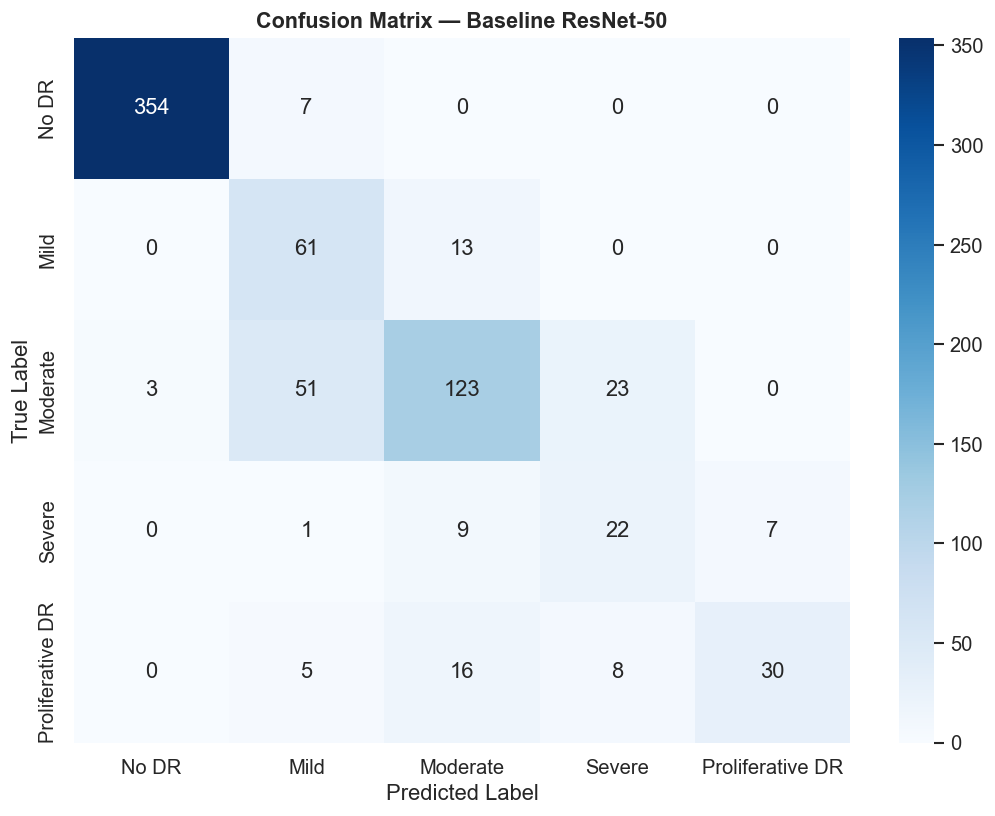

In [17]:
# Confusion Matrix
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[DR_GRADES[i] for i in range(5)],
            yticklabels=[DR_GRADES[i] for i in range(5)], ax=ax)
ax.set_title('Confusion Matrix — Baseline ResNet-50', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_resnet50_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

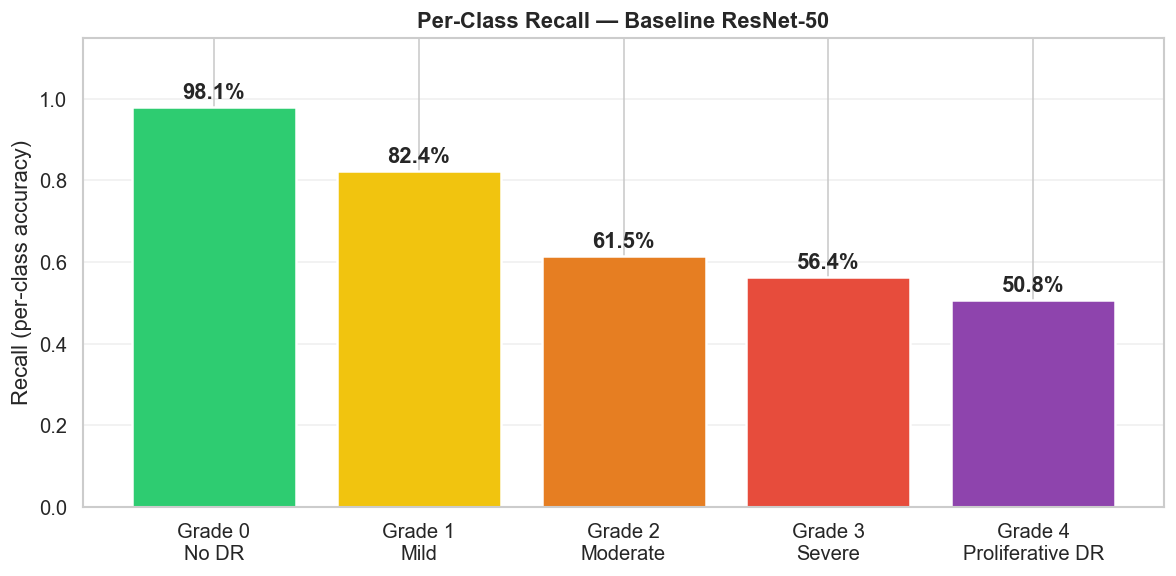

In [18]:
# Per-class accuracy
fig, ax = plt.subplots(figsize=(10, 5))

per_class_acc = []
for grade in range(5):
    mask = labels == grade
    if mask.sum() > 0:
        acc_g = (preds[mask] == grade).mean()
    else:
        acc_g = 0.0
    per_class_acc.append(acc_g)

bars = ax.bar(
    range(5), per_class_acc,
    color=[DR_COLORS[i] for i in range(5)],
    edgecolor='white', linewidth=1.5
)
for i, (bar, acc_val) in enumerate(zip(bars, per_class_acc)):
    ax.text(i, acc_val + 0.02, f'{acc_val:.1%}', ha='center', fontweight='bold')

ax.set_xticks(range(5))
ax.set_xticklabels([f'Grade {i}\n{DR_GRADES[i]}' for i in range(5)])
ax.set_ylabel('Recall (per-class accuracy)')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Recall — Baseline ResNet-50', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_resnet50_per_class_recall.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Results

In [19]:
# Save history
history_path = LOG_DIR / 'baseline_resnet50_fold0_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'History saved: {history_path}')

# Save metrics summary
metrics = {
    'model': 'Baseline ResNet-50 (no CBAM)',
    'best_epoch': int(np.argmax(history['val_kappa'])) + 1,
    'accuracy': float(accuracy_score(labels, preds)),
    'quadratic_kappa': float(cohen_kappa_score(labels, preds, weights='quadratic')),
    'referable_auc': float(auc_val),
    'hyperparameters': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'focal_gamma': FOCAL_GAMMA,
        'image_size': IMAGE_SIZE,
        'dropout': MC_DROPOUT_RATE,
        'device': 'cpu',
    }
}

metrics_path = RESULTS_DIR / 'baseline_resnet50_fold0_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved: {metrics_path}')
print(f'\nBaseline checkpoint: {CHECKPOINT_DIR / "baseline_resnet50_fold0_best.pth"}')

History saved: c:\Projects\dr-detect\outputs\logs\baseline_resnet50_fold0_history.json
Metrics saved: c:\Projects\dr-detect\outputs\results\baseline_resnet50_fold0_metrics.json

Baseline checkpoint: c:\Projects\dr-detect\outputs\checkpoints\baseline_resnet50_fold0_best.pth


## 9. Summary

| Component | Choice |
|-----------|--------|
| Backbone | ResNet-50 (ImageNet V2, **no CBAM**) |
| Head | Dropout(0.5) → Linear(2048, 5) |
| Loss | Focal Loss (γ=2.0) + per-class α |
| Optimizer | AdamW (lr=1e-4, wd=1e-4) |
| Scheduler | CosineAnnealingLR |
| AMP | ✗ (CPU mode) |
| Preprocessing | Ben Graham (crop + Gaussian blur norm) |
| Epochs | 5 |
| Batch size | 4 (fits 16 GB RAM) |

This baseline serves as the **control experiment**. The CBAM-augmented model should outperform it if attention helps the network focus on clinically relevant regions.